In [8]:
import pandas as pd 
df_siscan = pd.read_parquet("SISCAN_MAMOGRAFIA_2024_MENOR_TRATADO.parquet")

In [9]:
len(df_siscan)

200

In [11]:
for column in df_siscan.columns:
    print("Campos encontrados para coluna ", column)
    print(df_siscan[column].unique(), "\n")

Campos encontrados para coluna  Unnamed: 0
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199] 

Campos encontrados para coluna  CO_SEQ_SISCAN_MAMOGRAFIA_RESID
[267701937 267701938 267701939 267701940 296609371 267701942 267701943
 2724407

In [18]:
df_rs = df_siscan[df_siscan.UF_Residencia=="43 Rio Grande do Sul"]
df_rs.drop(columns=["UF_Residencia_Sigla", "UF_Residencia", "Ano_Resultado"], inplace=True)

In [19]:
df_rs.head()

,ID_Sequencial_Exame,Municipio_Residencia,Ano_Competencia,Ano_Mes_Competencia,Raca_Cor,Idade,Escolaridade,Risco_Elevado_Cancer,Exame_Clinico_Anterior,Fez_Mamografia_Anterior,...,Tempo_Exame,Intervalo_Resultado,Intervalo_Solicitacao,ID_Anonimizado_Paciente,Tempo_Mamografia_Anterior,Tamanho_Nodulo,Ano_Mes_Resultado,Nodulo_Caroco_Requisicao,Categoria_BI_RADS,Numero_Requisicao
191522,304350910,Passo Fundo,2024,202408,Branca,52,NaN,Não,Informação inconsistente,Sim,...,Até 30 dias,11 - 20 dias,0 - 10 dias,34717563,1 ano,NaN,None,Não,Categoria 2,111438470
191523,299734549,Sapiranga,2024,202407,Branca,60,NaN,Não,Nunca Examinadas,Não Sabe,...,31 - 60 dias,21 - 30 dias,> 30 dias,44876411,NaN,NaN,None,Não,Categoria 2,111772175
191524,304350911,São Sepé,2024,202411,Branca,70,NaN,Não,Sim,Sim,...,Até 30 dias,21 - 30 dias,21 - 30 dias,51062859,Mesmo ano,NaN,None,Não,Categoria 2,114859216
191525,304350912,Ijuí,2024,202408,Branca,60,NaN,Sim,Sim,Sim,...,mais de 60,11 - 20 dias,> 30 dias,40301998,1 ano,NaN,None,"Sim, ambas",Categoria 0,112782351
191527,304350913,Bento Gonçalves,2024,202411,Branca,60,NaN,Não,Sim,Sim,...,Até 30 dias,11 - 20 dias,11 - 20 dias,35876102,2 anos,NaN,None,Não,Categoria 2,115901641


## Limpeza dos Dados

## Analise dos Dados

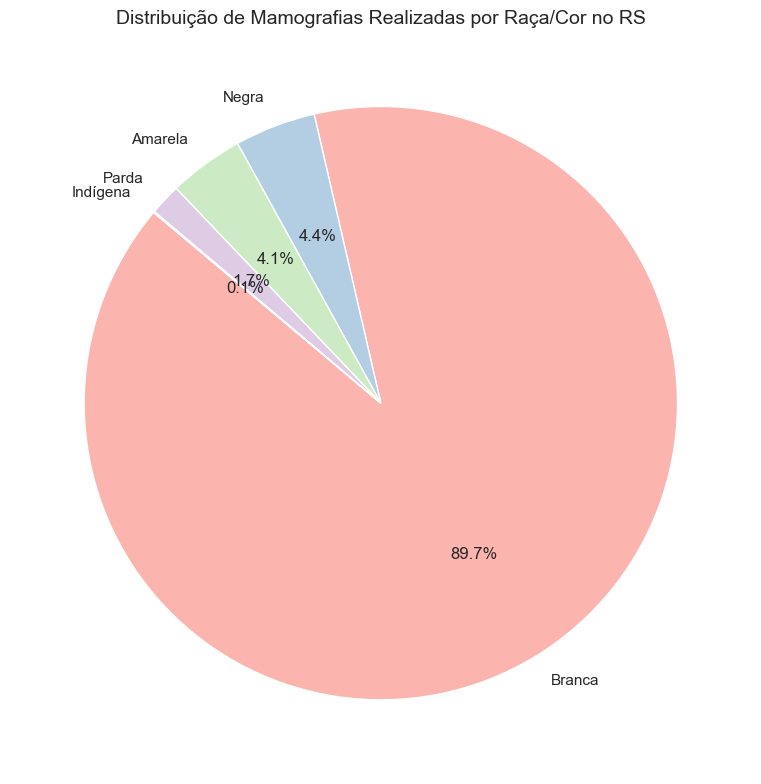

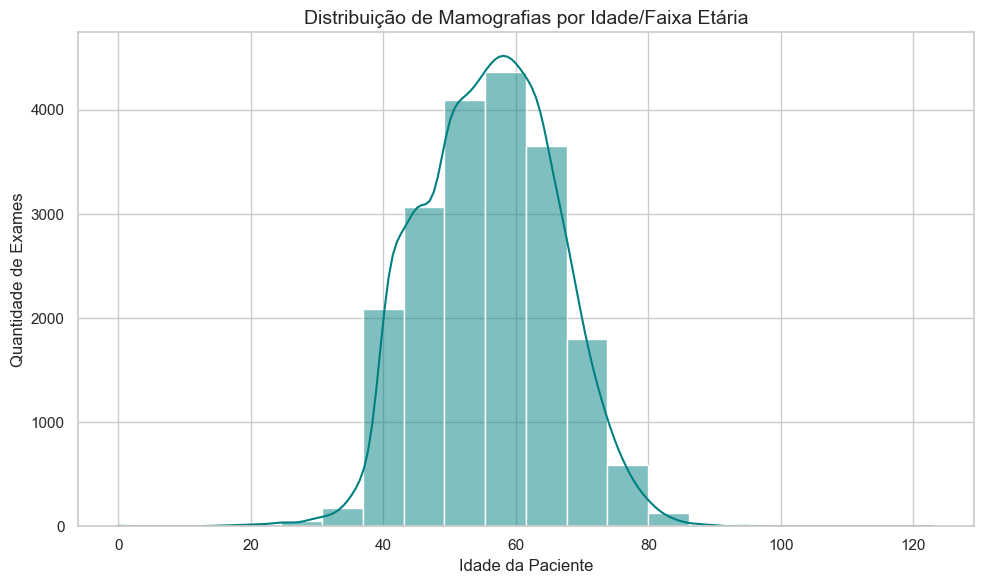

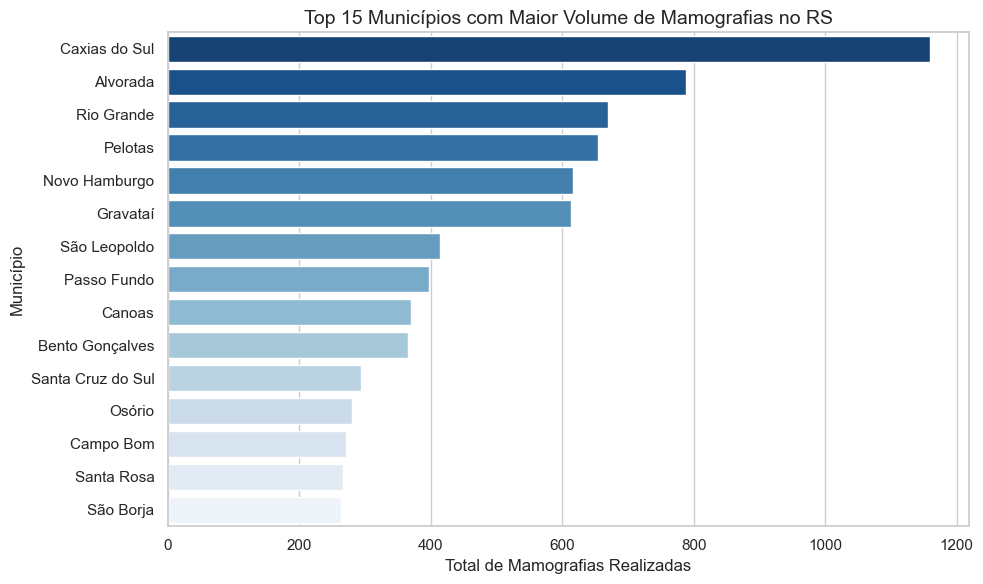

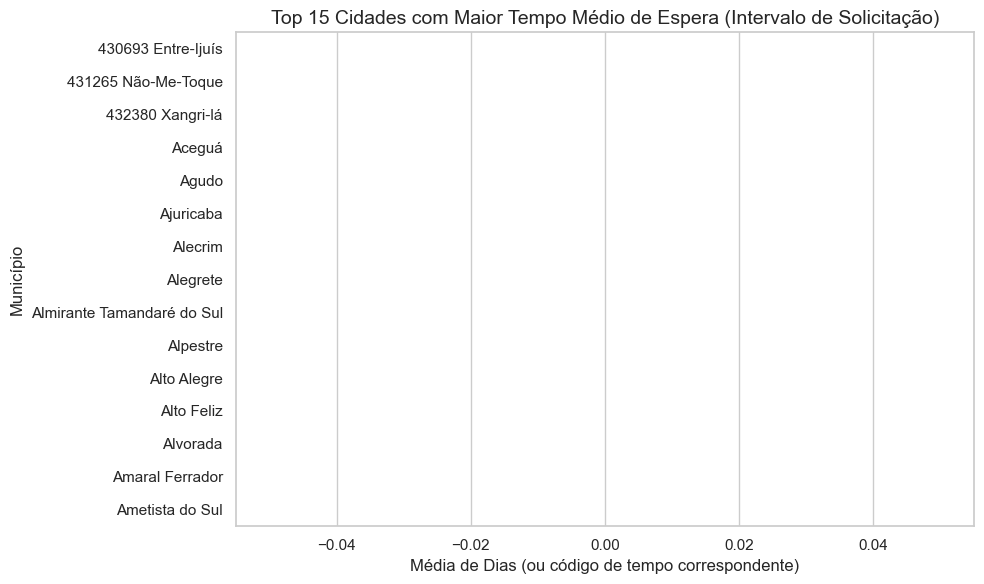

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo para os gráficos ficarem mais limpos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==============================================================================
# 1. Gráfico de Pizza: Número de mamografias por Raça/Cor
# ==============================================================================
plt.figure(figsize=(8, 8))

# Conta a quantidade de registros por Raça/Cor
dados_raca = df_rs["Raca_Cor"].value_counts()

plt.pie(
    dados_raca,
    labels=dados_raca.index,
    autopct="%1.1f%%",  # Mostra a porcentagem com uma casa decimal
    startangle=140,
    colors=sns.color_palette("Pastel1"),
)

plt.title("Distribuição de Mamografias Realizadas por Raça/Cor no RS", fontsize=14)
plt.tight_layout()
plt.show()


# ==============================================================================
# 2. Histograma: Mamografias por Idade (ou Faixa Etária)
# ==============================================================================
plt.figure()

# Nota: Se a sua coluna "Faixa_Etaria" for de texto (ex: "50-59 anos"),
# usamos um gráfico de barras (countplot). Se for a idade numérica, o histplot resolve.
if df_rs["Idade"].dtype in ["int64", "float64"]:
    sns.histplot(
        data=df_rs, x="Idade", kde=True, bins=20, color="teal"
    )
    plt.xlabel("Idade da Paciente")
else:
    # Se for texto/categoria, ordena as barras por frequência ou ordem alfabética
    sns.countplot(
        data=df_rs,
        x="Idade",
        order=df_rs["Idade"].value_counts().index,
        palette="viridis",
    )
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Faixa Etária")

plt.title("Distribuição de Mamografias por Idade/Faixa Etária", fontsize=14)
plt.ylabel("Quantidade de Exames")
plt.tight_layout()
plt.show()


# ==============================================================================
# 3. Gráfico de Barras: Municípios que mais realizam mamografias (Top 15)
# ==============================================================================
plt.figure()

# Filtra os 15 municípios com maior volume de exames
top_municipios = df_rs["Municipio_Residencia"].value_counts().head(15)

sns.barplot(
    x=top_municipios.values,
    y=top_municipios.index,
    palette="Blues_r",
    hue=top_municipios.index,
    legend=False,
)

plt.title("Top 15 Municípios com Maior Volume de Mamografias no RS", fontsize=14)
plt.xlabel("Total de Mamografias Realizadas")
plt.ylabel("Município")
plt.tight_layout()
plt.show()


# ==============================================================================
# 4. Gráfico de Barras: Média do intervalo de solicitação por cidade (Top 15 Maiores Médias)
# ==============================================================================
plt.figure()

# Agrupa por cidade, calcula a média do intervalo e pega as 15 que mais demoram
# Nota: Certifique-se de que a coluna de intervalo foi convertida para numérica antes
df_rs["Intervalo_Solicitacao"] = pd.to_numeric(
    df_rs["Intervalo_Solicitacao"], errors="coerce"
)

media_intervalo_por_cidade = (
    df_rs.groupby("Municipio_Residencia")["Intervalo_Solicitacao"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

sns.barplot(
    x=media_intervalo_por_cidade.values,
    y=media_intervalo_por_cidade.index,
    palette="Oranges_r",
    hue=media_intervalo_por_cidade.index,
    legend=False,
)

plt.title(
    "Top 15 Cidades com Maior Tempo Médio de Espera (Intervalo de Solicitação)",
    fontsize=14,
)
plt.xlabel("Média de Dias (ou código de tempo correspondente)")
plt.ylabel("Município")
plt.tight_layout()
plt.show()

In [24]:
df_rs["Intervalo_Solicitacao"].unique()

array([nan])